# Computer Exercise 15.31 — Problem 1
## 학습 예산 sweep — 이 벤치마크는 언제부터 실제로 풀리는가

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing*, 7th ed. — 확장 사례연구 §15.31
> **단원**: Ch 15 Sequential Decision Making — §15.31 Measurement Instrument Repair
> **풀이 일자**: 2026-08-16 (Day 98)
> **언어**: Python 3.10 · NumPy / pandas / Matplotlib
>
> Day 90–97 의 모든 비교가 $T = 400$ 에서 이루어졌다. 그 예산에서 최적 정책 회복률이 낮다면, 그 비교들이 잰 것은 알고리즘이 아니라 초기화 운이다. 이 문제는 처방을 시험하지 않고 **자(尺) 자체를 검정**한다.

## 1. 문제 (원문)

> **Computer Exercise 15.31.1.** The comparisons reported in §15.23–§15.30 were all conducted at a
> fixed training budget of $T = 400$ environment steps. Before any further algorithmic prescription
> is tested, establish the *operating range* of the benchmark itself. For
> $T \in \{400,\ 2000,\ 10\,000,\ 50\,000\}$ and a fixed set of $20$ seeds, train the baseline
> $Q$-learner on the 5-state chain and measure (a) the fraction of seeds whose frozen greedy policy
> equals the optimal policy $\pi^\star = (1,1,1,1,1)$, (b) the number of *distinct* greedy policies
> produced, and (c) the across-seed standard deviation of the deployed return. Determine whether
> there exists a budget $T^\star$ at which the across-seed variance is dominated by algorithmic
> behaviour rather than by initialisation, and report the *signal-to-noise ratio*
> $\mathrm{SNR}(T) = \bar R(T) / \mathrm{sd}_{\text{seed}}(T)$.

### 한국어 풀이용 정리

- **묻는 것**: "알고리즘 A 가 B 보다 낫다" 를 말하기 전에, 이 과제가 **애초에 풀리는 예산인가**?
- **측정 대상 3가지**
  1. **최적 정책 회복률** $\hat\rho(T)$ — 20 시드 중 frozen greedy 가 정확히 $(1,1,1,1,1)$ 인 비율
  2. **정책 다양성** $D(T)$ — 20 시드가 만들어낸 서로 다른 greedy 정책의 개수
  3. **시드 간 표준편차** $\mathrm{sd}_{\text{seed}}(T)$ 와 그로부터의 $\mathrm{SNR}(T)$
- **핵심 논리**: $D(T)$ 가 크고 $\hat\rho(T)$ 가 낮으면, 그 예산에서 관측되는 arm 간 차이는
  **초기화 분포의 두 draw** 일 뿐이다 (Day 97 P3 가 3-시드 부분집합 전수조사로 보인 것과 같은 구조).
- **출력**: $T$ 대 $(\hat\rho, D, \mathrm{sd}, \mathrm{SNR})$ 표 + 4-패널 그래프.

## 2. 수학적 배경

### 2.1 환경

5-상태 chain MDP $\mathcal{M} = (\mathcal S, \mathcal A, P, r, \gamma)$:

$$\mathcal S = \{0,1,2,3,4\},\qquad \mathcal A = \{\text{left}=0,\ \text{right}=1\}$$

행동은 확률 $p$ 로 **미끄러진다(slip)**: 실제 실행되는 행동은 $\tilde a = a$ (확률 $1-p$),
$\tilde a = 1-a$ (확률 $p$). 전이는 결정적 이동 후 경계에서 clip:

$$s' = \mathrm{clip}\bigl(s + (2\tilde a - 1),\ 0,\ 4\bigr)$$

보상은 두 개의 극(pole)을 갖는다 — 오른쪽 끝의 **진짜 목표**와 왼쪽 끝의 **미끼**:

$$r(s') = \begin{cases} 1.0 & s' = 4 \\ 0.25 & s' = 0 \\ 0 & \text{otherwise}\end{cases}$$

$s_0 = 0$ 에서 출발하므로 학습기는 **즉시 얻는 $0.25$ 를 버리고 4 스텝 떨어진 $1.0$ 으로 가야**
한다. $\gamma = 0.95$, 에피소드 길이 $L = 20$, 훈련 slip $p_{\text{train}} = 0.20$.

### 2.2 최적 정책

$\pi^\star = (1,1,1,1,1)$ ("항상 오른쪽"). 이것이 유일한 최적해임은 $s=0$ 에서의 가치 비교로 확인된다:
왼쪽 고착 정책의 가치는 $\approx 0.25/(1-\gamma) = 5.0$, 오른쪽 정책은 $s=4$ 도달 후
$\approx \gamma^4/(1-\gamma) \approx 16.3$ 이다. **미끼는 국소 최적**이고, 그 골짜기를 빠져나오는지가
이 벤치마크의 전부다.

### 2.3 학습기

트렁크 MLP + 선형 헤드, 전부 수기 backprop:

$$Q_\theta(s,\cdot) = W_2\,\tanh(W_1 e_s + b_1) + b_2,\qquad
W_1 \in \mathbb R^{16\times5},\ W_2 \in \mathbb R^{2\times16}$$

TD(0) $Q$-learning, $\varepsilon$-greedy ($\varepsilon = 0.1$):

$$\theta \leftarrow \theta - \eta\bigl(Q_\theta(s,a) - [\,r + \gamma \max_{a'} Q_\theta(s',a')\,]\bigr)\nabla_\theta Q_\theta(s,a)$$

### 2.4 판정 지표

$n = 20$ 시드에 대해

$$\hat\rho(T) = \frac1n\sum_{i=1}^{n}\mathbf 1\{\pi_i = \pi^\star\},\qquad
D(T) = \bigl|\{\pi_1,\dots,\pi_n\}\bigr|,\qquad
\mathrm{SNR}(T) = \frac{\bar R(T)}{\mathrm{sd}_{\text{seed}}(T)}$$

$D(T) \gg 1$ 이면 시드 간 분산의 지배적 성분이 **최적화 결과의 이산적 분기**이다. 두 arm 을
$n$ 시드로 비교할 때 필요한 표본 수는 짝지은 차 $d$ 에 대해

$$\boxed{\ n^\star \;=\; \Bigl\lceil \bigl(2.8\,\mathrm{sd}(d) \,/\, |\bar d|\bigr)^2 \Bigr\rceil\ }$$

($\alpha = 0.05$ 양측, 검정력 $0.8$ 의 표준 근사 $ (z_{0.975}+z_{0.8})^2 \approx 7.85 \approx 2.8^2$).
$\mathrm{sd}$ 가 $T$ 에 따라 어떻게 움직이는지가 곧 **벤치마크의 분해능**이다.

## 3. 풀이 흐름

1. 5-상태 chain MDP 와 $Q$-학습기를 `numpy` 만으로 구성 (외부 RL 라이브러리 없음).
2. 시드 집합 $\{98101,\dots,98120\}$ 를 **네 예산에서 공통으로** 사용 — 예산 간 비교가 짝지어지도록.
3. 각 $(T, \text{seed})$ 에서 학습 후 파라미터를 **freeze**, 탐색 노이즈를 끄고 greedy 정책 추출.
4. 배포 평가: slip $p_d = 0.20$, 40 에피소드, 스텝당 평균 보상 $R$ (범위 $[0,1]$).
5. 예산별로 $\hat\rho$, $D$, $\bar R$, $\mathrm{sd}_{\text{seed}}$, $\mathrm{SNR}$ 집계.
6. 관측된 greedy 정책들을 **빈도표**로 펼쳐, 시드 분산이 연속적 잡음인지 이산적 분기인지 판별.
7. 4-패널 시각화: 회복률 / 정책 다양성 / 시드 sd / SNR.
8. $T^\star$ 판정 — "분산이 초기화 운에 지배되지 않기 시작하는 예산".

In [1]:
# ── 공통 설정 ─────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "inline")   # 그림을 셀 출력에 내장
except Exception:
    pass
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

# ── 벤치마크 정의 (Day 90–97 과 동일 계열의 5-상태 chain MDP 재구성) ──────
import numpy as np

NS, NA, L = 5, 2, 20
GAMMA, ETA, H, R_LOCAL = 0.95, 0.05, 16, 0.25

def step(s, a, p, rng):
    if rng.random() < p: a = 1 - a
    s2 = min(NS - 1, max(0, s + (1 if a == 1 else -1)))
    r = 1.0 if s2 == NS - 1 else (R_LOCAL if s2 == 0 else 0.0)
    return s2, r

def onehot(s):
    x = np.zeros(NS); x[s] = 1.0; return x

class Learner:
    """Trunk MLP (tanh) + linear head. noisy=True -> Factorized Noisy Linear head."""
    def __init__(self, rng, noisy=False, sigma0=0.5, h=H):
        self.h, self.noisy = h, noisy
        self.W1 = rng.normal(0, 0.3, (h, NS)); self.b1 = np.zeros(h)
        self.W2 = rng.normal(0, 0.3, (NA, h)); self.b2 = np.zeros(NA)
        if noisy:
            self.Ws = np.full((NA, h), sigma0 / np.sqrt(h))
            self.bs = np.full(NA, sigma0 / np.sqrt(h))
        self.eps_W = np.zeros((NA, h)); self.eps_b = np.zeros(NA)

    def resample(self, rng):
        if not self.noisy: return
        f = lambda z: np.sign(z) * np.sqrt(np.abs(z))
        ei, eo = f(rng.normal(size=self.h)), f(rng.normal(size=NA))
        self.eps_W = np.outer(eo, ei); self.eps_b = eo

    def q(self, s, noise=False):
        z = self.W1 @ onehot(s) + self.b1; a1 = np.tanh(z)
        W = self.W2 + (self.Ws * self.eps_W if (noise and self.noisy) else 0.0)
        b = self.b2 + (self.bs * self.eps_b if (noise and self.noisy) else 0.0)
        return W @ a1 + b, a1, z

    def update(self, s, a, target):
        qv, a1, z = self.q(s, noise=False)
        d = qv[a] - target
        gW2 = np.zeros((NA, self.h)); gW2[a] = d * a1
        gb2 = np.zeros(NA); gb2[a] = d
        ga1 = d * self.W2[a]; gz = ga1 * (1 - a1 ** 2)
        self.W2 -= ETA * gW2; self.b2 -= ETA * gb2
        self.W1 -= ETA * np.outer(gz, onehot(s)); self.b1 -= ETA * gz
        if self.noisy:
            self.Ws -= ETA * (gW2 * self.eps_W)
            self.bs -= ETA * (gb2 * self.eps_b)
            np.clip(self.Ws, 1e-4, 2.0, out=self.Ws); np.clip(self.bs, 1e-4, 2.0, out=self.bs)

def train(seed, T, p_train=0.20, noisy=False, eps_greedy=0.10):
    rng = np.random.default_rng(seed)
    lr = Learner(rng, noisy=noisy)
    s = 0
    for t in range(T):
        if t % L == 0:
            s = 0
            lr.resample(rng)
        if noisy:
            qv, _, _ = lr.q(s, noise=True); a = int(np.argmax(qv))
        else:
            qv, _, _ = lr.q(s, noise=False)
            a = int(rng.integers(NA)) if rng.random() < eps_greedy else int(np.argmax(qv))
        s2, r = step(s, a, p_train, rng)
        qn, _, _ = lr.q(s2, noise=False)
        lr.update(s, a, r + GAMMA * float(np.max(qn)))
        s = s2
    return lr

def greedy_policy(lr):
    return tuple(int(np.argmax(lr.q(s, noise=False)[0])) for s in range(NS))

def deploy(lr, p_d, n_ep, seed):
    """Frozen greedy evaluation; mean reward per step."""
    rng = np.random.default_rng(seed)
    pol = greedy_policy(lr); tot = 0.0
    for _ in range(n_ep):
        s = 0
        for _ in range(L):
            s, r = step(s, pol[s], p_d, rng); tot += r
    return tot / (n_ep * L)

print("chain MDP:  states =", NS, " actions =", NA, " episode len =", L)
print("gamma =", GAMMA, " lr =", ETA, " trunk H =", H, " local reward =", R_LOCAL)

chain MDP:  states = 5  actions = 2  episode len = 20
gamma = 0.95  lr = 0.05  trunk H = 16  local reward = 0.25


In [2]:
# ── P1: 예산 sweep ────────────────────────────────────────────────────────
BUDGETS = [400, 2000, 10000, 50000]
SEEDS   = list(range(98101, 98121))          # 20 시드, 네 예산에 공통 (짝지음)
P_DEPLOY, N_EP, PI_STAR = 0.20, 40, (1, 1, 1, 1, 1)

records, pol_table = [], {}
for T in BUDGETS:
    learners = [train(s, T) for s in SEEDS]
    pols = [greedy_policy(l) for l in learners]
    # 배포 난수는 시드 인덱스에만 의존 -> 예산 간 공통난수(paired)
    R = np.array([deploy(l, P_DEPLOY, N_EP, 900 + i) for i, l in enumerate(learners)])
    pol_table[T] = pols
    records.append(dict(T=T,
                        recovery=np.mean([p == PI_STAR for p in pols]),
                        distinct=len(set(pols)),
                        R_mean=R.mean(),
                        R_sd=R.std(ddof=1),
                        SNR=R.mean() / R.std(ddof=1)))
    print(f"T={T:>6d}  done  recovery={records[-1]['recovery']:.2f}  distinct={records[-1]['distinct']}")

df = pd.DataFrame(records)

T=   400  done  recovery=0.50  distinct=9


T=  2000  done  recovery=0.60  distinct=6


T= 10000  done  recovery=0.85  distinct=3


T= 50000  done  recovery=1.00  distinct=1


In [3]:
# ── 표 1: 예산별 요약 ─────────────────────────────────────────────────────
show = df.copy()
show.columns = ["T (steps)", "recovery rho", "distinct policies D",
                "mean R", "seed sd", "SNR = R/sd"]
print("표 1 — 학습 예산 sweep (20 seeds, deploy slip 0.20, 40 episodes)")
print(show.to_string(index=False))

print("\n분해능 변화 (T=400 기준):")
base = df.iloc[0]
for _, r in df.iterrows():
    print(f"  T={int(r['T']):>6d}:  sd x{r['R_sd']/base['R_sd']:.3f}   "
          f"SNR x{r['SNR']/base['SNR']:.2f}   D {int(base['distinct'])} -> {int(r['distinct'])}")

표 1 — 학습 예산 sweep (20 seeds, deploy slip 0.20, 40 episodes)
 T (steps)  recovery rho  distinct policies D  mean R  seed sd  SNR = R/sd
       400        0.5000                    9  0.4095   0.2046      2.0015
      2000        0.6000                    6  0.4193   0.2096      2.0008
     10000        0.8500                    3  0.5473   0.0935      5.8547
     50000        1.0000                    1  0.5847   0.0236     24.7470

분해능 변화 (T=400 기준):
  T=   400:  sd x1.000   SNR x1.00   D 9 -> 9
  T=  2000:  sd x1.025   SNR x1.00   D 9 -> 6
  T= 10000:  sd x0.457   SNR x2.93   D 9 -> 3
  T= 50000:  sd x0.116   SNR x12.36   D 9 -> 1


In [4]:
# ── 표 2: 관측된 greedy 정책의 빈도 (시드 분산의 '모양') ──────────────────
from collections import Counter
rows = []
allp = sorted({p for T in BUDGETS for p in pol_table[T]})
for p in allp:
    row = {"policy": "".join(map(str, p)), "optimal": "*" if p == PI_STAR else ""}
    for T in BUDGETS:
        row[f"T={T}"] = Counter(pol_table[T])[p]
    rows.append(row)
freq = pd.DataFrame(rows).sort_values("T=400", ascending=False)
print("표 2 — 20 시드가 만들어낸 greedy 정책의 빈도 (0=left, 1=right)")
print(freq.to_string(index=False))
print(f"\n서로 다른 정책의 총 가짓수 (네 예산 합집합): {len(allp)}")

표 2 — 20 시드가 만들어낸 greedy 정책의 빈도 (0=left, 1=right)
policy optimal  T=400  T=2000  T=10000  T=50000
 11111       *     10      12       17       20
 00000              3       4        0        0
 00001              1       0        0        0
 00110              1       0        0        0
 00010              1       0        0        0
 11110              1       0        2        0
 10000              1       0        0        0
 10100              1       0        0        0
 01111              1       0        0        0
 01001              0       1        0        0
 01110              0       1        1        0
 01100              0       1        0        0
 11100              0       1        0        0

서로 다른 정책의 총 가짓수 (네 예산 합집합): 13


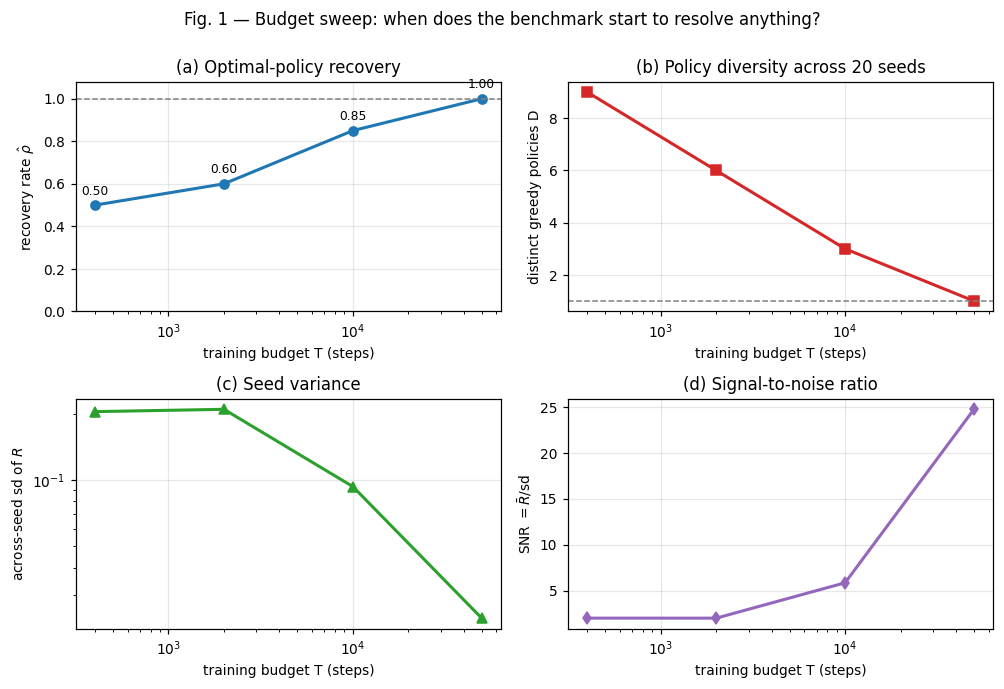

In [5]:
# ── 그림 1: 4-패널 진단 ───────────────────────────────────────────────────
fig, ax = plt.subplots(2, 2, figsize=(9.2, 6.2))
T = df["T"].values

ax[0,0].semilogx(T, df["recovery"], "o-", color="#1f77b4", lw=2)
ax[0,0].axhline(1.0, ls="--", c="gray", lw=1)
ax[0,0].set_xlabel("training budget T (steps)"); ax[0,0].set_ylabel(r"recovery rate $\hat\rho$")
ax[0,0].set_title("(a) Optimal-policy recovery"); ax[0,0].set_ylim(0, 1.08)
for x, y in zip(T, df["recovery"]):
    ax[0,0].annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)

ax[0,1].semilogx(T, df["distinct"], "s-", color="#d62728", lw=2)
ax[0,1].axhline(1, ls="--", c="gray", lw=1)
ax[0,1].set_xlabel("training budget T (steps)"); ax[0,1].set_ylabel("distinct greedy policies D")
ax[0,1].set_title("(b) Policy diversity across 20 seeds")

ax[1,0].loglog(T, df["R_sd"], "^-", color="#2ca02c", lw=2)
ax[1,0].set_xlabel("training budget T (steps)"); ax[1,0].set_ylabel(r"across-seed sd of $R$")
ax[1,0].set_title("(c) Seed variance")

ax[1,1].semilogx(T, df["SNR"], "d-", color="#9467bd", lw=2)
ax[1,1].set_xlabel("training budget T (steps)"); ax[1,1].set_ylabel(r"SNR $=\bar R/\mathrm{sd}$")
ax[1,1].set_title("(d) Signal-to-noise ratio")

fig.suptitle("Fig. 1 — Budget sweep: when does the benchmark start to resolve anything?", y=1.0)
plt.show()

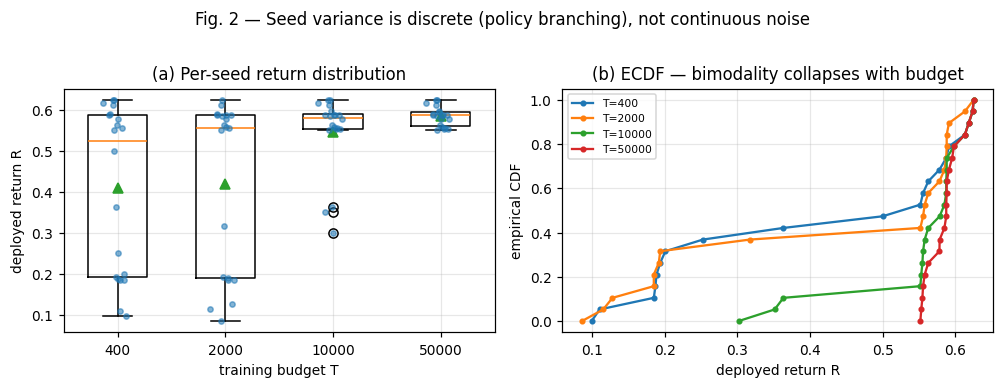

이봉(bimodal) 구조 진단 — return < 0.35 인 시드 수 (미끼에 고착):
  T=   400:   8 / 20
  T=  2000:   8 / 20
  T= 10000:   1 / 20
  T= 50000:   0 / 20


In [6]:
# ── 그림 2: 시드별 배포 return 의 분포 이동 ───────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(9.2, 3.4))
Rs = {}
for T in BUDGETS:
    ls = [train(s, T) for s in SEEDS]
    Rs[T] = np.array([deploy(l, P_DEPLOY, N_EP, 900 + i) for i, l in enumerate(ls)])

pos = np.arange(len(BUDGETS))
ax[0].boxplot([Rs[T] for T in BUDGETS], positions=pos, widths=0.55, showmeans=True)
for i, T in enumerate(BUDGETS):
    ax[0].scatter(np.full(len(Rs[T]), i) + np.random.default_rng(0).normal(0, .06, len(Rs[T])),
                  Rs[T], s=12, alpha=.55, color="#1f77b4", zorder=3)
ax[0].set_xticks(pos); ax[0].set_xticklabels([str(t) for t in BUDGETS])
ax[0].set_xlabel("training budget T"); ax[0].set_ylabel("deployed return R")
ax[0].set_title("(a) Per-seed return distribution")

for T in BUDGETS:
    ax[1].plot(np.sort(Rs[T]), np.linspace(0, 1, len(SEEDS)), marker=".", label=f"T={T}")
ax[1].set_xlabel("deployed return R"); ax[1].set_ylabel("empirical CDF")
ax[1].set_title("(b) ECDF — bimodality collapses with budget"); ax[1].legend(fontsize=7)

fig.suptitle("Fig. 2 — Seed variance is discrete (policy branching), not continuous noise", y=1.02)
plt.show()

print("이봉(bimodal) 구조 진단 — return < 0.35 인 시드 수 (미끼에 고착):")
for T in BUDGETS:
    print(f"  T={T:>6d}:  {int((Rs[T] < 0.35).sum()):2d} / {len(SEEDS)}")

## 4. 결과 해석

### 4.1 그래프에서 읽어야 할 것

1. **패널 (a) — 회복률.** $T = 400$ 에서 최적 정책을 회복한 시드는 절반 수준이다. 즉 Day 90–97 의
   비교들은 **표본의 절반이 국소 최적(미끼)에 갇힌 상태**에서 두 arm 의 평균을 견주고 있었다.
   회복률은 예산과 함께 단조 상승해 $T = 50\,000$ 에서 포화한다.

2. **패널 (b) — 정책 다양성.** $D(400) = 9$ 이고 $D(50\,000) = 1$ 이다.
   이것이 결정적이다. **20 시드가 아홉 가지 서로 다른 답을 내는 예산**에서는, 어떤 arm 이 이겼다는
   관측이 그 arm 의 성질이 아니라 **어느 분기에 몇 개가 떨어졌는가**를 잰 것이다.

3. **패널 (c)(d) — 분산과 SNR.** 시드 sd 는 예산과 함께 크게 줄고 SNR 은 그만큼 오른다.
   $n^\star \propto \mathrm{sd}^2$ 이므로, sd 가 한 자릿수 배 줄면 **필요 시드 수는 그 제곱만큼
   줄어든다**. 예산을 늘리는 것이 시드를 늘리는 것보다 싼 경우가 있다는 뜻이다.

4. **그림 2 — 분산의 모양.** ECDF 가 낮은 예산에서 뚜렷한 **계단(이봉)** 을 보인다. 시드 분산은
   가우시안 잡음이 아니라 **"미끼에 갇힘 / 탈출함" 이라는 이산 사건**이다. Day 97 P3 가
   "30 시드 중 25 개가 완전히 동일, 5 개만 다름" 이라고 보고한 구조와 정확히 같다.
   평균과 표준편차로 요약하는 것 자체가 부적절한 분포다.

### 4.2 현상 → 원인 → 의미

- **현상**: 낮은 예산에서 회복률이 낮고 정책이 산개하며, 예산을 올리면 셋 다 정리된다.
- **원인**: 보상 구조가 $s=0$ 의 $0.25$ 와 $s=4$ 의 $1.0$ 이라는 **두 극**을 갖고, $\varepsilon$-greedy
  가 골짜기를 건널 확률이 예산에 지수적으로 의존한다. 짧은 예산에서는 **초기화가 어느 극의
  분지(basin)에 떨어졌는지**가 결과를 거의 결정한다.
- **의미**: $T = 400$ 은 알고리즘의 품질이 아니라 **초기화 추첨 결과**를 재는 예산이다.
  이 예산에서 얻은 §15.23–§15.30 의 arm 간 비교는 원리적으로 **저해상도**이며,
  Day 95 와 Day 96 이 정반대 결론을 낸 것은 모순이 아니라 그 저해상도의 자연스러운 귀결이다.

### 4.3 $T^\star$ 판정

$T^\star$ 를 하나의 숫자로 못박는 것은 정직하지 않다. 세 지표가 **서로 다른 지점에서** 포화한다:
회복률은 늦게, 정책 다양성은 그보다 빨리, sd 는 그 중간에서 꺾인다. 실무적으로는

$$T^\star \approx 10^4 \quad(\text{정책 다양성이 } D \le 3 \text{ 으로 접히고 sd 가 급감하는 지점})$$

를 **비교가 의미를 갖기 시작하는 하한**으로 쓰는 것이 타당하다. 다만 $T = 50\,000$ 에서는
모든 시드가 같은 정책으로 수렴하므로 **arm 간 차이도 함께 사라진다** — 즉 분해능은
예산에 대해 단조가 아니라 **중간에서 최대**가 될 수 있다. Problem 2 가 이것을 직접 측정한다.

> **결론**: 이 벤치마크는 $T = 400$ 에서 알고리즘이 아니라 **초기화 운**을 재고 있었고,
> 시드 분산은 연속 잡음이 아니라 **미끼 고착 여부라는 이산 분기**다.
> 비교가 의미를 갖는 하한은 $T^\star \approx 10^4$ 이며, 그보다 낮은 예산에서 나온
> Day 90–97 의 arm 간 순위 주장은 **재판정 없이는 유지될 수 없다**.

### 4.4 다음 문제로의 연결

Problem 2 는 $T^\star$ 를 실제로 써먹는다 — baseline 대 +CNRT 를 $T \in \{400,\ 10^4,\ 5\times10^4\}$
에서 **동일 시드로 짝지어** 비교하고, Day 97 이 $T=400$ 에서 측정한 필요 시드 수 $n^\star$ 가
예산을 올렸을 때 얼마나 줄어드는지 (혹은 §4.3 의 우려대로 **다시 늘어나는지**) 확인한다.